In [1]:
run(`git clone https://github.com/msz13/MacroFinanceScenarios.git`)

Cloning into 'MacroFinanceScenarios'...


Process(`git clone https://github.com/msz13/MacroFinanceScenarios.git`, ProcessExited(0))

In [2]:
cd("MacroFinanceScenarios")

### TODO

- IRF
- Słabe powiazanie trendu stopy procentowej i wzrostu dywidendy - może chodzić o konsumpcję
- obliczyć dla prior trend covariance 1%
- duze przedziały trendów - moze dodac oczekiwania
- duży przedział trendu erp, choć stabilny - może dododać rv, moze zawezic prior
- dodać SV
- dodac wzrost gdp/konsumpcji per capita`
- zrobić symulację

In [3]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()


  Activating project at `/content/MacroFinanceScenarios`
    Updating registry at `~/.julia/registries/General.toml`
   Installed GR_jll ───────────────────── v0.73.26+0
   Installed PDMats ───────────────────── v0.11.40
   Installed GR ───────────────────────── v0.73.26
   Installed ConsoleProgressMonitor ───── v0.1.2
   Installed StatisticalTraits ────────── v3.5.0
   Installed Accessors ────────────────── v0.1.45
   Installed NaturalSort ──────────────── v1.0.0
   Installed InitialValues ────────────── v0.3.1
   Installed NearestNeighbors ─────────── v0.4.27
   Installed AbstractMCMC ─────────────── v5.15.1
   Installed NaNMath ──────────────────── v1.1.4
   Installed Distances ────────────────── v0.10.12
   Installed Roots ────────────────────── v3.0.0
   Installed CodecInflate64 ───────────── v0.1.3
   Installed MuladdMacro ──────────────── v0.2.6
   Installed ZipArchives ──────────────── v2.6.0
   Installed Clustering ───────────────── v0.15.8
   Installed ProgressLogging ───────

In [5]:
Pkg.add("Distributions")

   Resolving package versions...
      Compat entries added for Distributions
    Updating `/content/MacroFinanceScenarios/Project.toml`
  [31c24e10] + Distributions v0.25.129
    Manifest No packages added to or removed from `/content/MacroFinanceScenarios/Manifest.toml`
Precompiling packages...
              ✗ MacroFinanceScenarios
  0 dependencies successfully precompiled in 3 seconds. 313 already precompiled.
  1 dependency errored.
  For a report of the errors see `julia> err`. To retry use `pkg> precompile`


In [6]:
Threads.nthreads(:default)


2

In [7]:
include("./src/TCVAR/TCVAR.jl")

[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7](cache misses: wrong dep version loaded (1))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a](cache misses: wrong dep version loaded (1))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Main.TCVAR

In [8]:
using .TCVAR
using DataFrames, XLSX, TimeSeries
using StatsBase
using LinearAlgebra
using Plots


In [9]:
df = DataFrame(XLSX.readtable("./data/ie_data.xlsx", "Data2"))
df.Date = Date.(df.Date)

data = TimeArray(df[!,[:Date, :CPI, :TBILL, Symbol("Rate GS10"), :Real_Price, Symbol(" Real_Dividend")]]; timestamp=:Date)
data = collapse(data, Dates.quarter, first)


369×5 TimeArray{Float64, 2, Date, Matrix{Float64}} 1934-01-01 to 2026-01-01
┌────────────┬─────────┬───────┬───────────┬────────────┬────────────────┐
│            │ CPI     │ TBILL │ Rate GS10 │ Real_Price │  Real_Dividend │
├────────────┼─────────┼───────┼───────────┼────────────┼────────────────┤
│ 1934-01-01 │    13.2 │  0.72 │      3.12 │    267.592 │        11.1912 │
│ 1934-04-01 │    13.3 │  0.15 │    3.0375 │    275.155 │          11.17 │
│ 1934-07-01 │    13.4 │  0.15 │     2.955 │    236.839 │        11.1492 │
│ 1934-10-01 │    13.5 │  0.27 │    2.8725 │    222.176 │        11.1286 │
│ 1935-01-01 │    13.6 │   0.2 │      2.79 │    228.181 │        11.0887 │
│ 1935-04-01 │    13.8 │  0.15 │     2.755 │    219.531 │        10.8471 │
│ 1935-07-01 │    13.7 │  0.15 │      2.72 │    260.517 │        10.7631 │
│ 1935-10-01 │    13.7 │   0.2 │     2.685 │    291.583 │        11.0078 │
│ 1936-01-01 │    13.8 │   0.2 │      2.65 │    334.154 │        11.6565 │
│ 1936-04-01 │    13.7 │

In [ ]:
colnames(data)

5-element Vector{Symbol}:
 :CPI
 :TBILL
 Symbol("Rate GS10")
 :Real_Price
 Symbol(" Real_Dividend")

In [10]:
cpi = (log.(data[:CPI]) .- log.(lag(data[:CPI], 4))) .* 100
g = (log.(data[Symbol(" Real_Dividend")]) .- log.(lag(data[Symbol(" Real_Dividend")], 4))) .* 100
dy = (data[Symbol(" Real_Dividend")] ./ data[:Real_Price]) .* 100

data = merge(cpi, data[:TBILL], data[Symbol("Rate GS10")], g, dy)
TimeSeries.rename!(data, [:CPI, :TBILL, :GS10, :G, :DY])

365×5 TimeArray{Float64, 2, Date, Matrix{Float64}} 1935-01-01 to 2026-01-01
┌────────────┬───────────┬───────┬────────┬───────────┬─────────┐
│            │ CPI       │ TBILL │ GS10   │ G         │ DY      │
├────────────┼───────────┼───────┼────────┼───────────┼─────────┤
│ 1935-01-01 │    2.9853 │   0.2 │   2.79 │ -0.919664 │ 4.85961 │
│ 1935-04-01 │   3.69046 │  0.15 │  2.755 │  -2.93379 │ 4.94101 │
│ 1935-07-01 │   2.21411 │  0.15 │   2.72 │  -3.52368 │ 4.13146 │
│ 1935-10-01 │   1.47061 │   0.2 │  2.685 │  -1.09212 │ 3.77517 │
│ 1936-01-01 │   1.45988 │   0.2 │   2.65 │   4.99397 │ 3.48837 │
│ 1936-04-01 │ -0.727276 │   0.2 │ 2.6575 │   15.2858 │ 3.47222 │
│ 1936-07-01 │    1.4493 │  0.15 │  2.665 │   24.4369 │ 3.66324 │
│ 1936-10-01 │   2.16615 │  0.13 │ 2.6725 │   34.0922 │  3.8287 │
│ 1937-01-01 │   2.15062 │  0.17 │   2.68 │   39.7752 │ 4.15009 │
│ 1937-04-01 │   4.28637 │  0.56 │   2.65 │   36.9032 │ 4.58554 │
│ 1937-07-01 │   4.22598 │  0.28 │   2.62 │   31.7335 │ 4.92859 │


In [11]:
presample, y = data[Date(1954,01,01):Date(1959,12,31)], data[Date(1960,01,01):Date(2025,12,31)]

#display(presample)
#display(data)

term = presample[:GS10] .- presample[:TBILL]
rs = presample[:TBILL] .- presample[:CPI]
erp = presample[:DY] .+ presample[:G] .- rs

[mean(values(presample[:CPI])), mean(values(rs)), mean(values(term)), mean(values(presample[:G])), mean(values(erp))]

5-element Vector{Float64}:
 1.4320577437307191
 0.807942256269281
 1.0120833333333332
 2.4147391777108527
 5.57664431134042

In [12]:
pre_std = [std(values(presample[:CPI])), std(values(rs)), std(values(presample[:TBILL])), std(values(term)), std(values(presample[:GS10])), std(values(presample[:G])), std(values(erp)), std(values(presample[:DY]))]
pre_std .^ 2

8-element Vector{Float64}:
  2.0120107383475285
  1.8127801948409297
  0.9315304347826088
  0.2548259057971014
  0.4356259057971014
 28.90333053101063
 24.830690333341312
  0.4444848410008812

In [16]:
n = 5 #number of observatin variables
nt = 5 #number of trends
p=4

# Minnesota prior for the cycle VAR (mean-zero cycle => white-noise prior, δ = 0).
# ψ is the prior scale of diag(Σc); with d = n+2 it equals the prior mean of diag(Σc).
cycle_prior = MinnesotaPrior(.2, n, p, [2., 1., .1, 25., 1], n + 2; δ = zeros(n))

# prior mean of the cycle covariance, used for initial states / simulation below
cycle_covariance_mean = Matrix(cycle_prior.Ψ) / (cycle_prior.d - n - 1)

priors = (
        initial_trend_mean = [2., .5, 1., 2., 5.],
        initial_cycle_mean = zeros(n),
        initial_trend_covariance = diagm(fill(1,nt)),
        trend_covariance_df = 100,
        trend_covariance_mean = diagm([2., 1., 1., 2., 1.].^2 ./ 400),
        )

(initial_trend_mean = [2.0, 0.5, 1.0, 2.0, 5.0], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 … 0 0; 0 1 … 0 0; … ; 0 0 … 1 0; 0 0 … 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.01 0.0 … 0.0 0.0; 0.0 0.0025 … 0.0 0.0; … ; 0.0 0.0 … 0.01 0.0; 0.0 0.0 … 0.0 0.0025])

# osobny trend term i erp




In [17]:
observation_trend_mapping  = [1 0 0 0 0
                              1 1 0 0 0
                              1 1 1 0 0
                              0 0 0 1 0
                              0 1 0 -1 1 ]



@time trend_states_samples, cycle_states_samples, trend_covariance_samples, betas_samples, sigmas_samples = TCVAR.gibbs_sampler(convert(Matrix{Union{Missing, Float64}}, values(y)), observation_trend_mapping, priors, cycle_prior; burnin = 20_000, n_samples = 25_000, thin=25, logging=true)

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.68)
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95)

Gibbs sampler: draw 2000 of 45000
Gibbs sampler: draw 4000 of 45000
Gibbs sampler: draw 6000 of 45000
Gibbs sampler: draw 8000 of 45000
Gibbs sampler: draw 10000 of 45000
Gibbs sampler: draw 12000 of 45000
Gibbs sampler: draw 14000 of 45000
Gibbs sampler: draw 16000 of 45000
Gibbs sampler: draw 18000 of 45000
Gibbs sampler: draw 20000 of 45000
Gibbs sampler: draw 22000 of 45000
Gibbs sampler: draw 24000 of 45000
Gibbs sampler: draw 26000 of 45000
Gibbs sampler: draw 28000 of 45000
Gibbs sampler: draw 30000 of 45000
Gibbs sampler: draw 32000 of 45000
Gibbs sampler: draw 34000 of 45000
Gibbs sampler: draw 36000 of 45000
Gibbs sampler: draw 38000 of 45000
Gibbs sampler: draw 40000 of 45000
Gibbs sampler: draw 42000 of 45000
Gibbs sampler: draw 44000 of 45000
1816.826627 seconds (1.72 G allocations: 1.860 TiB, 20.97% gc time, 0.01% compilation time)


([-1.0602370873947322 0.36631469109271775 … 1.5686697201239377 0.034035964667101244; -1.2578851712662162 0.42159367549219917 … 1.862699394005697 0.025558080026897575; … ; 0.4704834663664655 1.9588375372254685 … 1.0083872441803188 0.19259367785299766; 0.7956202913161823 1.5547308700811677 … 0.12436556285571236 0.17125196258178574], [-4.32003600114335 -2.473226351239292 … -6.398728830184643 -0.5071686858904494; -4.017840775964729 -2.3173850281917683 … -4.924236644507165 -0.4750252388449692; … ; -1.2317674835103678 -0.15007012125004848 … -0.6968004060511337 -0.25103953964917936; -0.9070481925161318 -0.5517068100751797 … -1.5508335847365742 -0.29850622081759176], [2.247621656227602 3.0637142851084067 … 9.582690261112832 0.5956057332225507; 1.7226941752192744 2.8228306760106747 … 8.879776757030504 0.5268497640881135; … ; 1.9842843844370057 3.6042803963954397 … 2.624647549231012 0.5601738184768007; 2.3284909717268865 3.247064514009947 … 1.7786698133016516 0.5673909362446881])

1 st version

Gibbs sampler: draw 2000 of 2000
484.571342 seconds (110.89 M allocations: 117.624 GiB, 20.84% gc time, 2.81% compilation time)

In [18]:
trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95)
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95)

([-1.0602370873947322 0.36631469109271775 … 1.5686697201239377 0.034035964667101244; -1.2578851712662162 0.42159367549219917 … 1.862699394005697 0.025558080026897575; … ; 0.4704834663664655 1.9588375372254685 … 1.0083872441803188 0.19259367785299766; 0.7956202913161823 1.5547308700811677 … 0.12436556285571236 0.17125196258178574], [-4.32003600114335 -2.473226351239292 … -6.398728830184643 -0.5071686858904494; -4.017840775964729 -2.3173850281917683 … -4.924236644507165 -0.4750252388449692; … ; -1.2317674835103678 -0.15007012125004848 … -0.6968004060511337 -0.25103953964917936; -0.9070481925161318 -0.5517068100751797 … -1.5508335847365742 -0.29850622081759176], [2.247621656227602 3.0637142851084067 … 9.582690261112832 0.5956057332225507; 1.7226941752192744 2.8228306760106747 … 8.879776757030504 0.5268497640881135; … ; 1.9842843844370057 3.6042803963954397 … 2.624647549231012 0.5601738184768007; 2.3284909717268865 3.247064514009947 … 1.7786698133016516 0.5673909362446881])

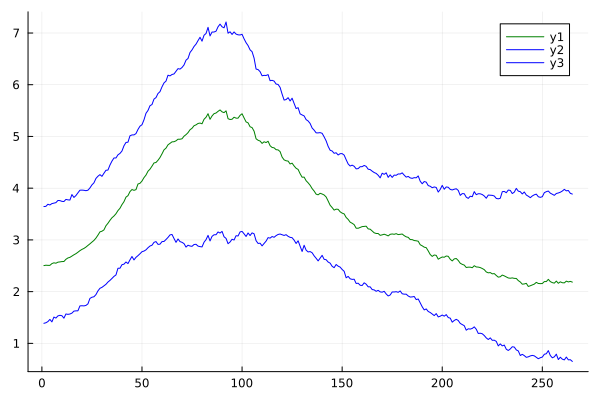

In [19]:
st = 1
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

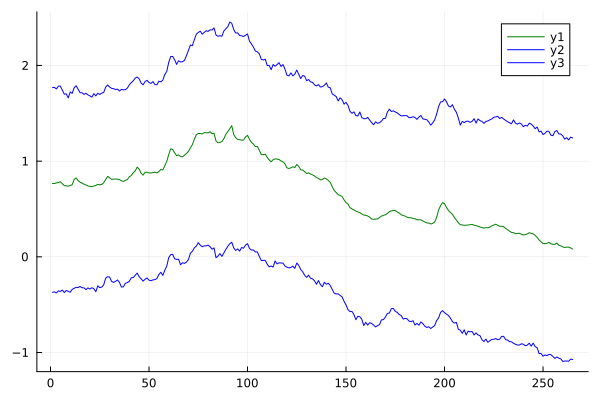

In [20]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

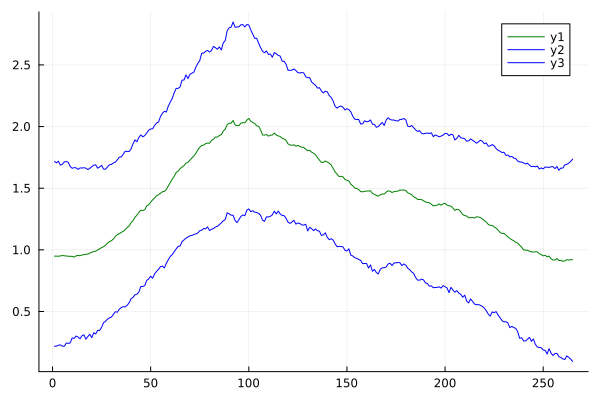

In [21]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

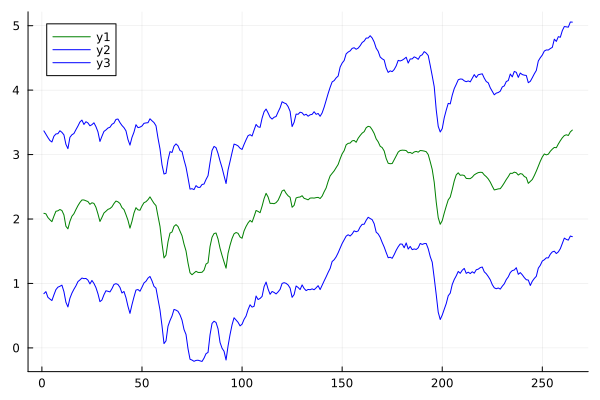

In [22]:
st = 4
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

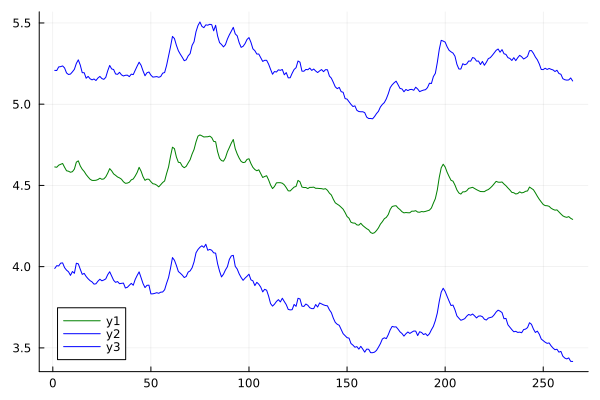

In [20]:
st = 5
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

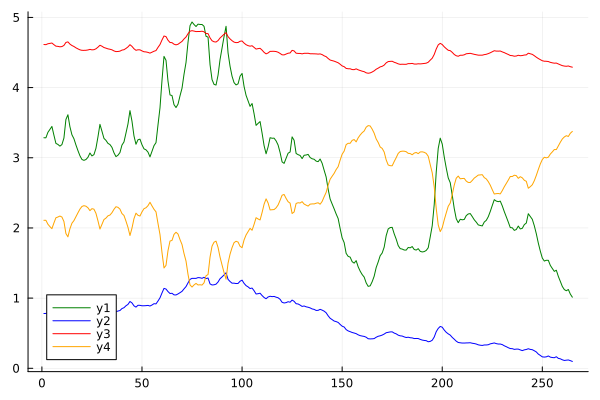

In [27]:
plot(trend_states_mean[:,2] .+ trend_states_mean[:,5] .- trend_states_mean[:,4], color="green" )
plot!(trend_states_mean[:,2], color="blue" )
plot!(trend_states_mean[:,5], color="red" )
plot!(trend_states_mean[:,4], color="orange" )


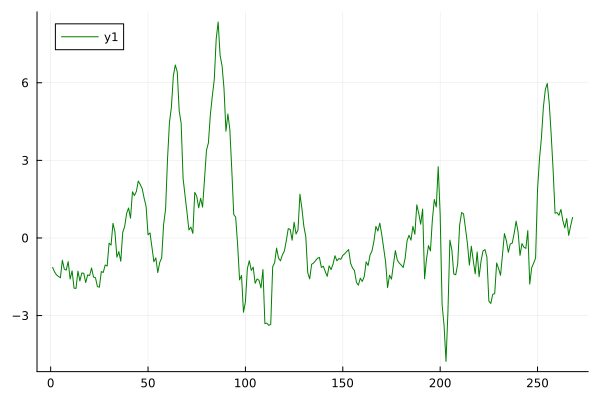

In [22]:
st=1
plot(cycle_states_mean[:,st], color="green" )

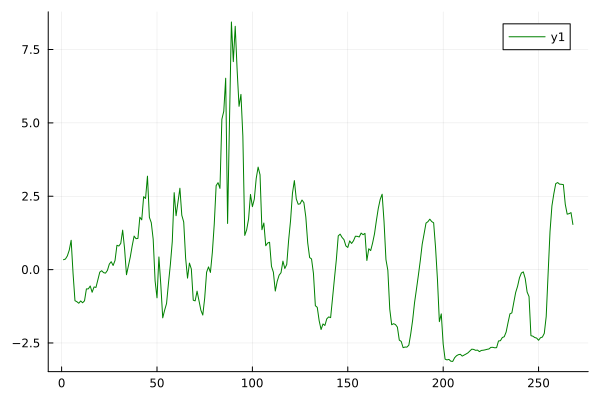

In [23]:
st=2
plot(cycle_states_mean[:,st], color="green" )

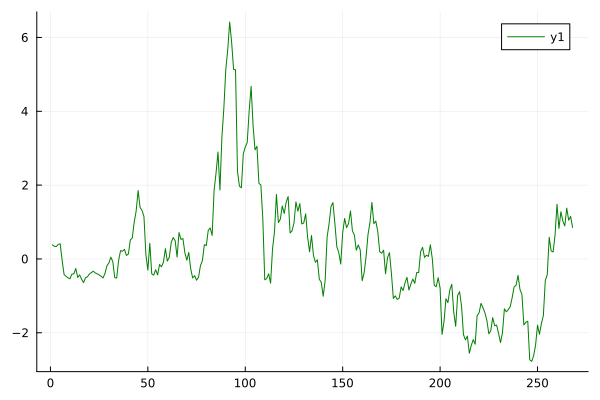

In [24]:
st=3
plot(cycle_states_mean[:,st], color="green" )

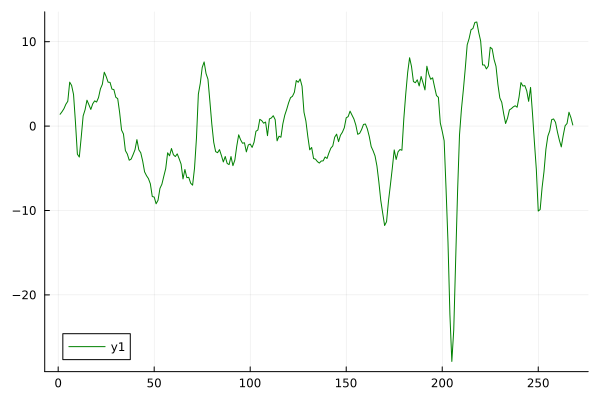

In [25]:
st=4
plot(cycle_states_mean[:,st], color="green" )

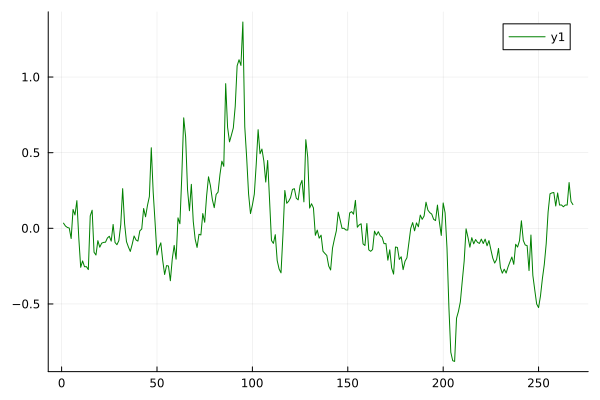

In [28]:
st=5
plot(cycle_states_mean[:,st], color="green" )

In [30]:
summarystats(trend_covariance_samples)

Summary Statistics

  parameters      mean       std      mcse    ess_bulk   ess_tail      rhat    ⋯
      Symbol   Float64   Float64   Float64     Float64    Float64   Float64    ⋯

         Στ1    0.0133    0.0023    0.0001    767.4991   776.8670    0.9990    ⋯
         Στ2    0.0006    0.0008    0.0000    600.8749   655.1011    1.0009    ⋯
         Στ3    0.0007    0.0008    0.0000    773.5480   849.8517    0.9996    ⋯
         Στ4   -0.0011    0.0017    0.0001    811.4544   927.2589    1.0024    ⋯
         Στ5    0.0002    0.0008    0.0000    901.1238   944.3411    1.0002    ⋯
         Στ6    0.0006    0.0008    0.0000    600.8749   655.1011    1.0009    ⋯
         Στ7    0.0032    0.0005    0.0000    872.4008   703.1755    1.0006    ⋯
         Στ8    0.0002    0.0004    0.0000    875.5720   753.8830    0.9999    ⋯
         Στ9   -0.0008    0.0007    0.0000    940.5194   769.3462    1.0031    ⋯
        Στ10    0.0002    0.0004    0.0000    836.8923   872.9888    0.9996    ⋯
       

In [31]:
summarystats(betas_samples)

Summary Statistics

  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

          β1   -0.0359    0.0252    0.0008    987.0703    944.1954    0.9992   ⋯
          β2   -0.0249    0.0355    0.0012    843.1573    762.6804    1.0008   ⋯
          β3   -0.1903    0.0942    0.0034    756.8504    975.4709    1.0004   ⋯
          β4   -0.0030    0.0082    0.0003   1014.1009    768.6579    1.0008   ⋯
          β5   -0.0064    0.0402    0.0013    970.9287    954.8808    0.9992   ⋯
          β6   -0.0108    0.0339    0.0011    918.0327    840.8951    0.9991   ⋯
          β7    0.0273    0.0466    0.0016    898.7730    942.0177    1.0023   ⋯
          β8    0.0107    0.1119    0.0038    880.1136    900.6339    0.9998   ⋯
          β9   -0.0057    0.0100    0.0003    812.0210    734.8435    1.0004   ⋯
         β10   -0.0049    0.0524    0.0017    961.5986    889.5448    1.0012   ⋯
       

In [32]:
summarystats(sigmas_samples)

Summary Statistics

  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

         Σc1    0.6817    0.0713    0.0030    570.6126    816.1813    0.9995   ⋯
         Σc2    0.1270    0.0436    0.0021    472.5585    943.0320    1.0017   ⋯
         Σc3    0.0917    0.0339    0.0014    623.2277    944.1954    0.9992   ⋯
         Σc4   -0.3906    0.1146    0.0036   1037.0029    944.1954    1.0008   ⋯
         Σc5    0.0099    0.0133    0.0005    664.2804    912.4941    1.0008   ⋯
         Σc6    0.1270    0.0436    0.0021    472.5585    943.0320    1.0017   ⋯
         Σc7    0.5809    0.0533    0.0019    806.8693    843.2654    0.9992   ⋯
         Σc8    0.2061    0.0286    0.0010    830.7383    901.5741    1.0004   ⋯
         Σc9   -0.0386    0.1056    0.0034    983.4733    907.7013    0.9996   ⋯
        Σc10    0.0000    0.0125    0.0004    877.5692    802.1065    1.0038   ⋯
       

In [ ]:
plot(betas_samples)

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

LoadError: The backend must not support the series type Val{:density}, and there isn't a series recipe defined.

In [33]:
Σc = mean(sigmas_samples).nt.mean
Σc = reshape(Σc, n, n)
display(Σc)

β = mean(betas_samples).nt.mean
β = reshape(β, n, n*p)
display(β[:,1:n])
display(β[:,n+1:n*2])
display(β[:,2*n+1:n*3])
display(β[:,3*n+1:n*4])
Στ = mean(trend_covariance_samples).nt.mean
Στ = reshape(Στ, nt, nt)
display(cov2cor(Στ))
display(diag(Στ) .^ .5)

5×5 Matrix{Float64}:
  0.681668     0.127008     0.0917251   -0.390617   0.00987904
  0.127008     0.580935     0.20613     -0.0385539  8.53067e-7
  0.0917251    0.20613      0.231958    -0.0743665  0.00898414
 -0.390617    -0.0385539   -0.0743665    4.81243    0.0427069
  0.00987904   8.53067e-7   0.00898414   0.0427069  0.0234892

5×5 Matrix{Float64}:
 -0.0358787   -0.0108316    0.0631399    0.803866    -0.00667311
 -0.0248675    0.0272925    0.0477202    0.146211    -0.0239403
 -0.190337     0.0106913   -0.205151     0.0720622   -0.0680392
 -0.00301076  -0.00565611  -0.00436851  -0.00454412  -0.000284092
 -0.00636614  -0.00492842  -0.00455862  -0.0636233   -0.00385751

5×5 Matrix{Float64}:
  0.0116791     0.0258096    0.033616    0.00829406    0.0131063
  0.0288407     0.0693485    0.77715     0.00325186    0.00916472
  0.00415723   -0.149011     0.304459   -0.0600327    -0.00902353
 -0.000916073   0.00019095   0.0162673  -0.000552886  -0.00149103
  0.00332785    0.00357342  -0.221054    0.00147482    0.00419809

5×5 Matrix{Float64}:
  0.0102862   -0.0168012   -0.0716379  -0.0586698   0.00222293
  0.00845947   0.0743523   -0.100771   -0.123729   -0.0990507
 -0.0152516    0.884918     0.065281    0.101491    0.260733
 -0.00118483  -0.00185295  -0.0339834  -0.0348581   0.0372006
  0.0101446   -0.0926074   -0.0389804  -0.0859949  -0.131349

5×5 Matrix{Float64}:
  0.191695    -0.000144954   0.00490997   0.0103225    0.0394049
  0.00151994   0.00262687    0.00229714   0.00137361  -0.00624435
 -0.0297521   -0.00521906    0.0111972    0.0488939    0.0836675
  0.900955     0.000155246   0.000321571  0.00260752   0.0168867
 -0.037615    -0.000690294  -0.000535194  0.00146754   0.0540264

5×5 Matrix{Float64}:
  1.0         0.0931289   0.108397   -0.0776665   0.0378511
  0.0931289   1.0         0.0690194  -0.121592    0.0663781
  0.108397    0.0690194   1.0        -0.0752172   0.0334712
 -0.0776665  -0.121592   -0.0752172   1.0        -0.112809
  0.0378511   0.0663781   0.0334712  -0.112809    1.0

5-element Vector{Float64}:
 0.11521564488547831
 0.05618786580385122
 0.055309636385596606
 0.1183371371326366
 0.05508315309596909

In [34]:
display(diag(Σc) .^ .5)
display(cov2cor(Σc))

display(diag(Στ) .^ .5)

5-element Vector{Float64}:
 0.8256317513631215
 0.7621912015737006
 0.4816204320802242
 2.1937257196619977
 0.15326171738607472

5×5 Matrix{Float64}:
  1.0         0.201827     0.230673   -0.215666   0.0780719
  0.201827    1.0          0.561529   -0.023058   7.30274e-6
  0.230673    0.561529     1.0        -0.0703866  0.121713
 -0.215666   -0.023058    -0.0703866   1.0        0.127023
  0.0780719   7.30274e-6   0.121713    0.127023   1.0

5-element Vector{Float64}:
 0.11521564488547831
 0.05618786580385122
 0.055309636385596606
 0.1183371371326366
 0.05508315309596909

In [ ]:
model = tc_var(observation_tend_mapping, β, Στ, Σc, priors.initial_trend_mean, priors.initial_cycle_mean, priors.initial_trend_covariance, cycle_covariance_mean)

initial_states = [trend_states_mean[end,:]; cycle_states_mean[end,:]]

n_samples = 2_000
T = 100
states = zeros(n_samples, T, 8)

observations = zeros(n_samples, T, n)

for s in 1:2_000
    states[s, :, :], observations[s, :, :] = sample(model, initial_states, T)
end


UndefVarError: UndefVarError: `observation_tend_mapping` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations, (3, 2, 1))[[1,2],:,:] ./400
periods = [1, 5, 10, 25]
freq = 4
assets_names = ["GDP", "CPI"]
ret_in_years = cum_returns_in_periods(transformed_scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations[:,:,[3,4]] , (3, 2, 1))
freq = 4

transformed_scenarios = transformed_scenarios[:,freq:freq:end,:]

periods = [1, 5, 10, 25]


assets_names = ["ShortRate", "LongRate"]
ret_in_years = transformed_scenarios = transformed_scenarios[:,periods,:]
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
n_observations = size(model.T,1)
n_trends = 4
n_time_steps = size(data,1)
n_draws = 1000
trends_states = zeros(n_draws, n_time_steps, n_trends)

for s in 1:n_draws
    state_smoothed_samples = carter_kohn_sampler(model, values(data))
    trends_states[s,:,:] = state_smoothed_samples[:, 1:n_trends]
end

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95)

UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.